## Load and Preprocess Data
`emg.csv: timestamp, emg_channel_1, emg_channel_2, emg_channel_3, emg_channel_4, emg_channel_5, emg_channel_6, emg_channel_7, emg_channel_8`

`finger_angles.csv: timestamp, THUMB, INDEX, MIDDLE, RING, PINKY`

In [1]:
# emg.csv:
# timestamp,emg_channel_1,emg_channel_2,emg_channel_3,emg_channel_4,emg_channel_5,emg_channel_6,emg_channel_7,emg_channel_8

# finger_angles.csv:
# timestamp,THUMB,INDEX,MIDDLE,RING,PINKY
import os
import pandas as pd
import numpy as np

def load_session_data(session_folder):
    """Loads EMG and finger angle data from a given session folder."""
    emg_path = os.path.join(session_folder, "emg.csv")
    finger_path = os.path.join(session_folder, "finger_angles.csv")
    emg_data = pd.read_csv(emg_path)
    finger_angles = pd.read_csv(finger_path)
    
    # Rectify and normalize EMG data for each session
    emg_channels = emg_data.columns[1:]
    rectified_emg_data = emg_data.copy()
    rectified_emg_data[emg_channels] = emg_data[emg_channels].abs()
    normalized_emg_data = rectified_emg_data.copy()
    normalized_emg_data[emg_channels] = rectified_emg_data[emg_channels].apply(lambda x: (x - x.mean()) / x.std())
    
    # Normalize finger angle data
    joint_angle_thresholds = {
        'thumb': (132.5, 157.5),
        'index': (60, 160),
        'middle': (40, 167.5),
        'ring': (30, 167.5),
        'pinky': (30, 167.5)
    }
    def normalize_finger_angle(data, joint):
        normalized_data = (data - joint_angle_thresholds[joint][0]) / (joint_angle_thresholds[joint][1] - joint_angle_thresholds[joint][0])
        return np.clip(normalized_data, 0, 1)

    finger_angles_normalized = finger_angles.copy()
    for joint in joint_angle_thresholds:
        finger_angles_normalized[joint.upper()] = normalize_finger_angle(finger_angles[joint.upper()], joint)

    return normalized_emg_data, finger_angles_normalized

# Load all sessions in the data/ directory
data_folder = "../data/"
session_folders = [os.path.join(data_folder, folder) for folder in os.listdir(data_folder) if os.path.isdir(os.path.join(data_folder, folder))]
session_data = [load_session_data(folder) for folder in session_folders]


### Low Pass Filter

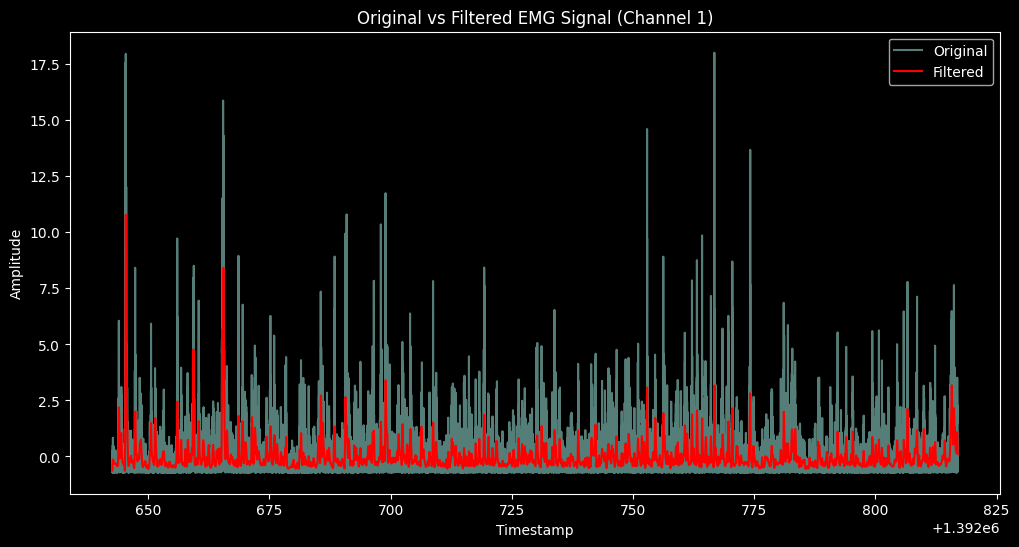

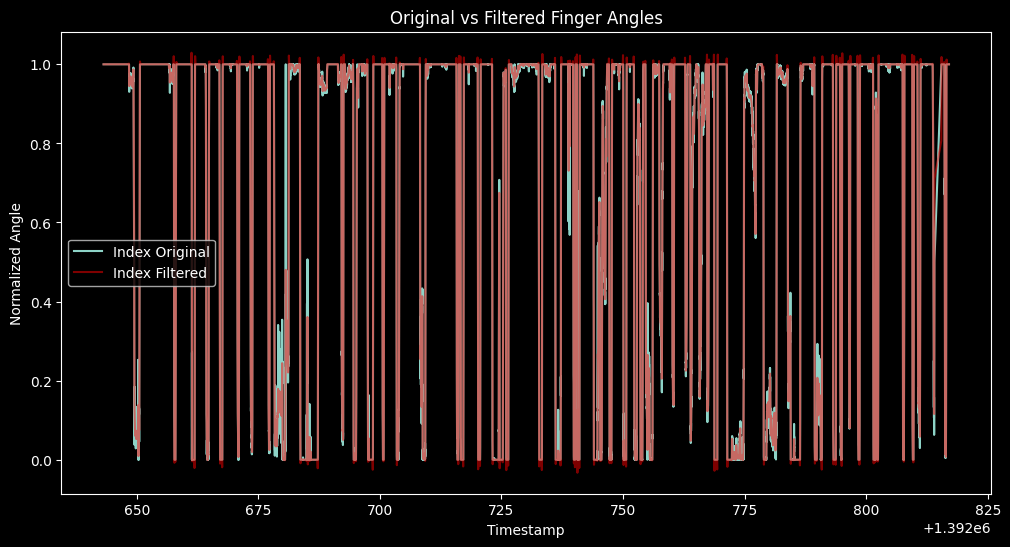

In [2]:
from scipy.signal import butter, filtfilt, resample
import matplotlib.pyplot as plt

def low_pass_filter(data, cutoff=4, fs=250, order=2):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

def estimate_sampling_frequency(timestamps):
    sampling_intervals = np.diff(timestamps)
    return int(1 / np.mean(sampling_intervals))

def resample_dataframe_signal(df, desired_rate, time_column='timestamp'):
    df = df.sort_values(by=time_column).reset_index(drop=True)
    data_columns = df.columns.drop(time_column)
    time_values = df[time_column].values
    start_time, end_time = time_values[0], time_values[-1]
    num_samples = int((end_time - start_time) * desired_rate)
    new_time_values = np.linspace(start_time, end_time, num=num_samples)
    
    resampled_data = {time_column: new_time_values}
    for col in data_columns:
        signal = df[col].interpolate(method='linear').values
        resampled_signal = resample(signal, num_samples)
        resampled_data[col] = resampled_signal
    
    return pd.DataFrame(resampled_data)

# Filter and resample each session with a visualization of filtered data
processed_sessions = []
plotted = False
for normalized_emg_data, finger_angles in session_data:
    emg_fs = estimate_sampling_frequency(normalized_emg_data['timestamp'].values)
    filtered_emg_data = normalized_emg_data.copy()
    for channel in filtered_emg_data.columns[1:]:
        filtered_emg_data[channel] = low_pass_filter(filtered_emg_data[channel], fs=emg_fs)
    
    # Resample
    finger_fs = estimate_sampling_frequency(finger_angles['timestamp'].values)
    resampled_emg_data = resample_dataframe_signal(filtered_emg_data, desired_rate=finger_fs, time_column='timestamp')
    
    # low pass filter the finger angles
    filtered_finger_angles = finger_angles.copy()
    for joint in finger_angles.columns[1:]:
        filtered_finger_angles[joint] = low_pass_filter(filtered_finger_angles[joint], fs=finger_fs, cutoff=10)
    
    processed_sessions.append((resampled_emg_data, filtered_finger_angles))
    
    # Plot original vs. filtered data for the first channel as a sanity check
    if not plotted:
        plotted = True
        # Plot EMG data
        plt.figure(figsize=(12, 6))
        plt.plot(normalized_emg_data['timestamp'], normalized_emg_data[filtered_emg_data.columns[1]], label='Original', alpha=0.6)
        plt.plot(filtered_emg_data['timestamp'], filtered_emg_data[filtered_emg_data.columns[1]], label='Filtered', color='red')
        plt.title("Original vs Filtered EMG Signal (Channel 1)")
        plt.xlabel("Timestamp")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.show()
        
        # Plot index angles vs filtered
        plt.figure(figsize=(12, 6))
        plt.plot(finger_angles['timestamp'], finger_angles['INDEX'], label='Index Original')
        plt.plot(filtered_finger_angles['timestamp'], filtered_finger_angles['INDEX'], label='Index Filtered', alpha=0.5, color='red')
        plt.title("Original vs Filtered Finger Angles")
        plt.xlabel("Timestamp")
        plt.ylabel("Normalized Angle")
        plt.legend()
        plt.show()
        
        

### Align

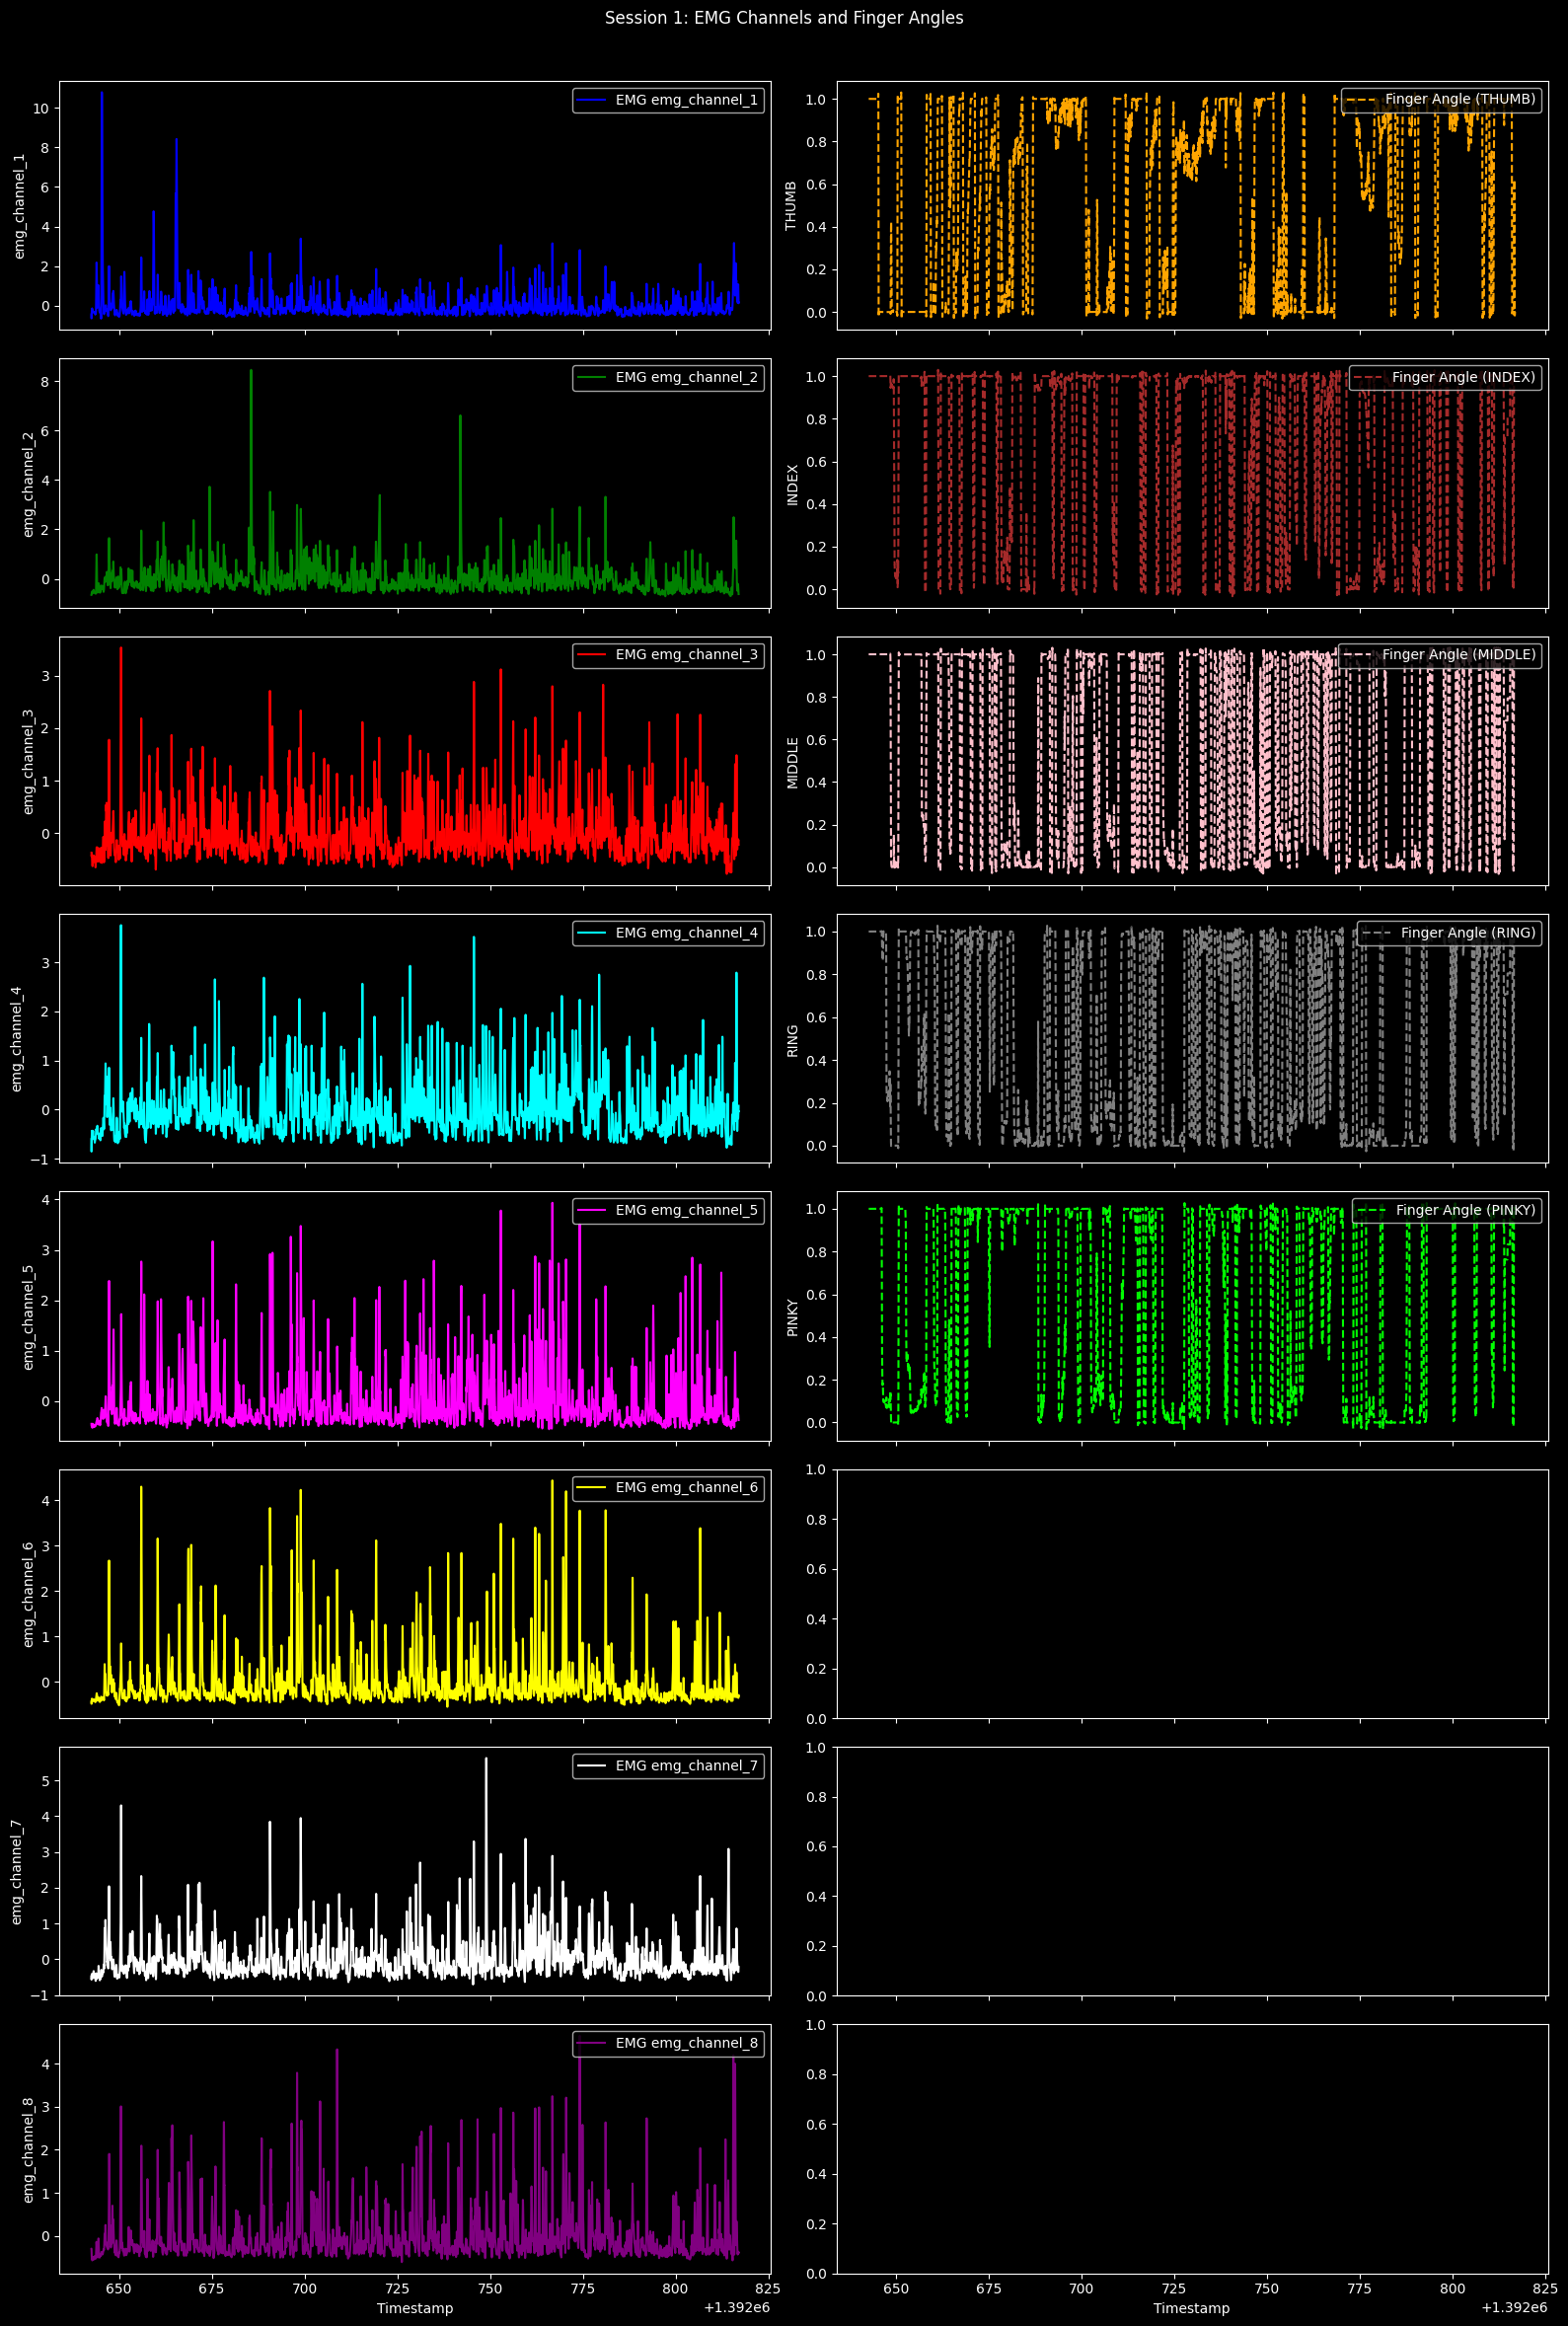

In [3]:
import itertools
import matplotlib.pyplot as plt

# Color cycles for distinguishing channels in each session plot
emg_colors = itertools.cycle(['blue', 'green', 'red', 'cyan', 'magenta', 'yellow', 'white', 'purple'])
finger_colors = itertools.cycle(['orange', 'brown', 'pink', 'gray', 'lime'])

aligned_data_sessions = []
plotted = False
for session_index, (resampled_emg_data, finger_angles_normalized) in enumerate(processed_sessions):
    # Sort data by timestamp for merging
    resampled_emg_data_sorted = resampled_emg_data.sort_values(by="timestamp").reset_index(drop=True)
    finger_angles_sorted = finger_angles_normalized.sort_values(by="timestamp").reset_index(drop=True)
    
    # Align EMG and finger data by the nearest timestamp
    aligned_data = pd.merge_asof(resampled_emg_data_sorted, finger_angles_sorted, on="timestamp", direction="nearest")
    aligned_data_sessions.append(aligned_data)
    
    if not plotted:
        plotted = True
        # Create a 2-column subplot for this session (8 EMG channels in left column + 5 finger angles in right column)
        fig, axes = plt.subplots(8, 2, figsize=(16, 24), sharex=True, gridspec_kw={'width_ratios': [1, 1]})
        
        # Plot each EMG channel on the left
        for i, channel in enumerate(resampled_emg_data.columns[1:]):
            color = next(emg_colors)
            axes[i, 0].plot(aligned_data['timestamp'], aligned_data[channel], label=f'EMG {channel}', color=color)
            axes[i, 0].set_ylabel(channel)
            axes[i, 0].legend(loc='upper right')
        
        # Plot each finger angle on the right
        for j, finger in enumerate(finger_angles_normalized.columns[1:]):
            color = next(finger_colors)
            axes[j, 1].plot(aligned_data['timestamp'], aligned_data[finger], label=f'Finger Angle ({finger})', color=color, linestyle='--')
            axes[j, 1].set_ylabel(finger)
            axes[j, 1].legend(loc='upper right')
        
        # General settings for the plot
        fig.suptitle(f"Session {session_index + 1}: EMG Channels and Finger Angles")
        axes[-1, 0].set_xlabel("Timestamp")
        axes[-1, 1].set_xlabel("Timestamp")
        plt.tight_layout(rect=[0, 0, 1, 0.97])  # Adjust layout to fit the suptitle
        plt.show()

# Combine all sessions into a single DataFrame for further analysis
combined_data = pd.concat(aligned_data_sessions, ignore_index=True)


In [4]:
# Define EMG features (X) and finger targets (y)
emg_channels = combined_data.columns[1:9]
X = combined_data[emg_channels].values
y = combined_data[['THUMB', 'INDEX', 'MIDDLE', 'RING', 'PINKY']].values

# Split data
train_val_split = int(len(combined_data) * 0.8)
val_test_split = int(len(combined_data) * 0.9)
X_train, y_train = X[:train_val_split], y[:train_val_split]
X_val, y_val = X[train_val_split:val_test_split], y[train_val_split:val_test_split]
X_test, y_test = X[val_test_split:], y[val_test_split:]

# Print data shapes
print("Training data shape:", X_train.shape, y_train.shape)
print("Validation data shape:", X_val.shape, y_val.shape)
print("Testing data shape:", X_test.shape, y_test.shape)

Training data shape: (131269, 8) (131269, 5)
Validation data shape: (16409, 8) (16409, 5)
Testing data shape: (16409, 8) (16409, 5)


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(y_train.shape[1], activation='sigmoid')
])

model.compile(optimizer=Adam(), loss=MeanSquaredError(), metrics=['r2_score'])

early_stopping = EarlyStopping(monitor='val_r2_score', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=200, validation_data=(X_val, y_val), batch_size=1024, callbacks=[early_stopping])

# Evaluate on the test set
test_loss, test_r2 = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}, Test R^2: {test_r2}")

Epoch 1/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1742 - r2_score: 0.0470 - val_loss: 0.1165 - val_r2_score: 0.2282
Epoch 2/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1348 - r2_score: 0.2639 - val_loss: 0.1065 - val_r2_score: 0.2957
Epoch 3/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1285 - r2_score: 0.3001 - val_loss: 0.1055 - val_r2_score: 0.3017
Epoch 4/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1252 - r2_score: 0.3168 - val_loss: 0.1061 - val_r2_score: 0.2974
Epoch 5/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1219 - r2_score: 0.3359 - val_loss: 0.1063 - val_r2_score: 0.2970
Epoch 6/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1200 - r2_score: 0.3473 - val_loss: 0.1013 - val_r2_score: 0.3306
Epoch 7/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1181 - r2_score: 0.3555 - val_loss: 0.1020 - val_r2_score: 0.3243
Epoch 8/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1169 - r2_score: 0.3619 - 

513/513 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


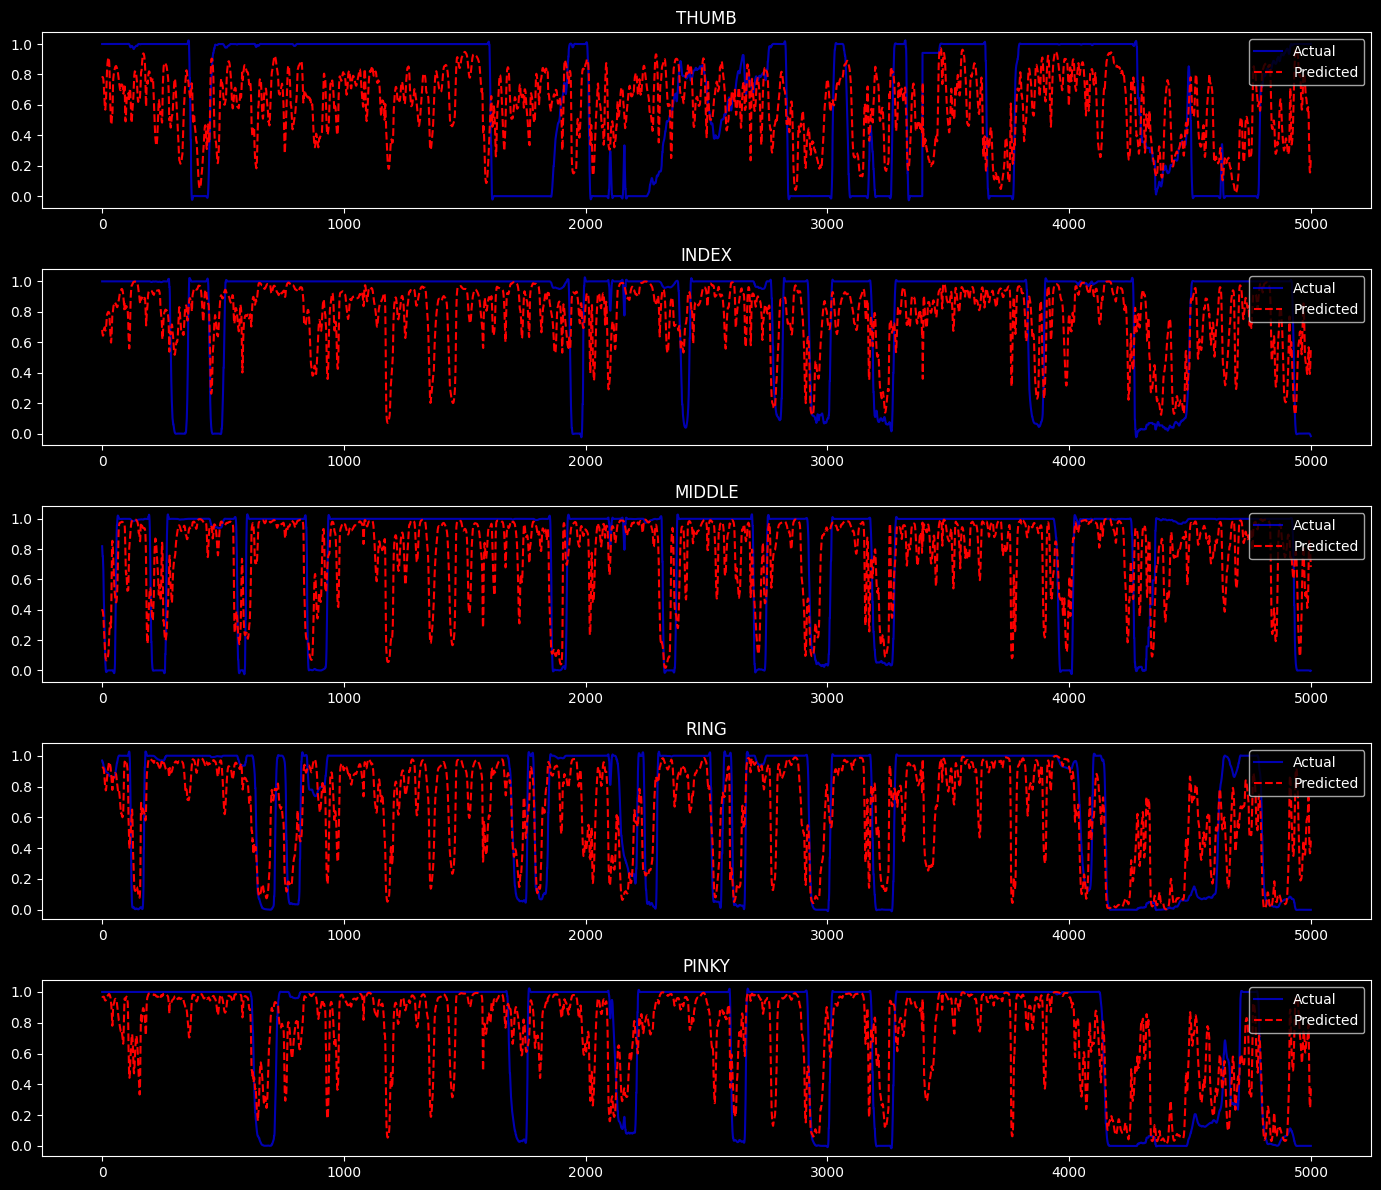

In [14]:
y_pred = model.predict(X_val)

def plot_predictions(y_true, y_pred, n_samples=5000):
    finger_names = ['THUMB', 'INDEX', 'MIDDLE', 'RING', 'PINKY']
    num_fingers = y_true.shape[1]
    fig, axes = plt.subplots(num_fingers, 1, figsize=(14, 12))
    
    for i in range(num_fingers):
        axes[i].plot(y_true[:n_samples, i], color='blue', alpha=0.7, label='Actual')
        axes[i].plot(y_pred[:n_samples, i], color='red', linestyle='--', label='Predicted')
        axes[i].set_title(f'{finger_names[i]}')
        axes[i].legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

plot_predictions(y_val, y_pred)

513/513 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


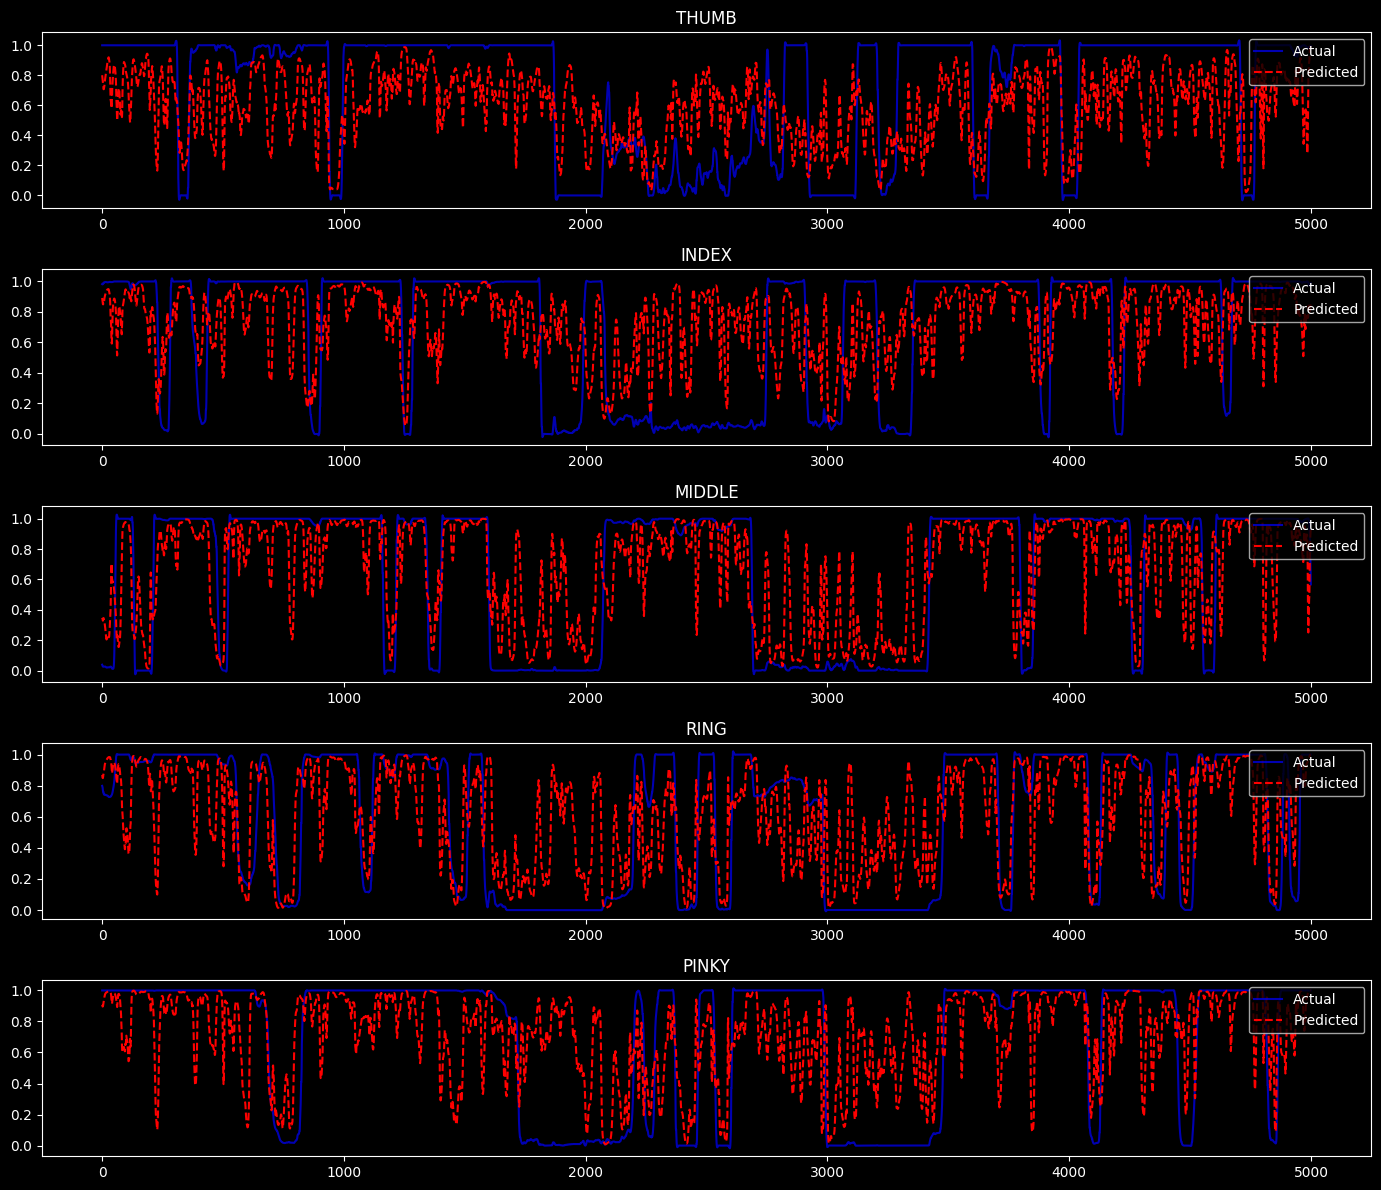

In [15]:
y_pred = model.predict(X_test)

plot_predictions(y_test, y_pred)

## Muscle Activation

In [43]:
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, r2_score
from scipy.interpolate import interp1d
import numpy as np

# Define the muscle activation model
def muscle_activation_model(emg_signal, d, alpha, gamma1, gamma2):
    """Applies the muscle activation model to EMG data, incorporating fractional EMD and recursive filtering."""
    beta1 = gamma1 + gamma2
    beta2 = gamma1 * gamma2
    activation = np.zeros(len(emg_signal))
    
    # Interpolation function for fractional delays
    interpolate_emg = interp1d(np.arange(len(emg_signal)), emg_signal, bounds_error=False, fill_value="extrapolate")
    
    for t in range(2, len(emg_signal)):
        delay_index = t - d
        if delay_index >= 0:
            delayed_value = interpolate_emg(delay_index)  # Interpolated EMG at fractional delay
            activation[t] = alpha * delayed_value - beta1 * activation[t - 1] - beta2 * activation[t - 2]
    
    return activation

# Nonlinear muscle activation function
def nonlinear_muscle_activation(u, A=-3):
    """Transforms the neural activation to muscle activation."""
    denom = np.exp(A) - 1
    return (np.exp(A * u) - 1) / (denom if denom != 0 else 1e-10)

# Objective function to minimize
def objective_function(params, emg_signals, target_angles):
    """Objective function to minimize the mean squared error between estimated and target angles."""
    d, alpha, gamma1, gamma2, A = params
    mse_total = 0
    
    for emg_signal, target_angle in zip(emg_signals, target_angles):
        activation = muscle_activation_model(emg_signal, d, alpha, gamma1, gamma2)
        v = nonlinear_muscle_activation(activation, A)
        mse_total += mean_squared_error(target_angle, v)
    
    return mse_total / len(emg_signals)

# Prepare the full training set for optimization
target_columns = ['THUMB', 'INDEX', 'MIDDLE', 'RING', 'PINKY']
emg_channels = ['emg_channel_1', 'emg_channel_2', 'emg_channel_3', 'emg_channel_4', 'emg_channel_5', 'emg_channel_6', 'emg_channel_7', 'emg_channel_8']

# Aggregate EMG signals and corresponding target angles across all channels and target columns
emg_signals = [aligned_data_sessions[0][channel].values for channel in emg_channels]
target_angles = [aligned_data_sessions[0][target].values for target in target_columns]

# Set initial parameter guesses and constraints
initial_params = [45, 1.0, 0.5, 0.5, -3]
bounds = [(10, 75), (0.8, 1.2), (-0.95, 0.95), (-0.95, 0.95), (-3, 0)]

# Optimize parameters using the entire dataset
result = minimize(objective_function, initial_params, args=(emg_signals, target_angles), bounds=bounds)
optimized_params = result.x

# Calculate the R² score using the optimized parameters
activations = [muscle_activation_model(emg, optimized_params[0], optimized_params[1], optimized_params[2], optimized_params[3]) for emg in emg_signals]
predictions = [nonlinear_muscle_activation(activation, optimized_params[4]) for activation in activations]
r2_scores = [r2_score(target, pred) for target, pred in zip(target_angles, predictions)]

# Display results
print("Optimized Parameters (d, alpha, gamma1, gamma2, A):", optimized_params)
print("Average R² Score:", np.mean(r2_scores))


Optimized Parameters (d, alpha, gamma1, gamma2, A): [45.   1.   0.5  0.5 -3. ]
Average R² Score: -5.375478913134513
